In [0]:
# ============================================================
#  FERMENTATION HEAT BALANCE  —  DISTURBANCE ONLY (no control)
#  Step disturbance of +3 °C injected at 40 % of run (134.4 h)
#  Coolant flow is fixed at nominal value throughout.
#  Use this to verify the disturbance is visible before adding
#  the PID controller.
# ============================================================

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ─────────────────────────────────────────────────────────────
#  WORT TEMPERATURE SETPOINT
# ─────────────────────────────────────────────────────────────
duration = 336          # hr  (14 days)
t_base   = np.linspace(0, duration, 1500)

Tset_arr = np.zeros(len(t_base))
for i, ti in enumerate(t_base):
    if   ti < 48:   Tset_arr[i] = 18
    elif ti < 168:  Tset_arr[i] = 20
    elif ti < 240:  Tset_arr[i] = 22
    elif ti < 300:  Tset_arr[i] = 18
    else:           Tset_arr[i] = 18 - (16/36) * (ti - 300)

Tset_func = interp1d(t_base, Tset_arr, fill_value="extrapolate")

# ─────────────────────────────────────────────────────────────
#  DISTURBANCE
#  A true +3 °C step is applied directly to the wort temperature
#  state at t_dist.  The simulation is split into two segments:
#    Segment 1: t = 0  → t_dist   (undisturbed)
#    Segment 2: t = t_dist → end  (initial T_wort raised by +3 K)
#  This guarantees exactly +3 °C appears in the output regardless
#  of heat transfer rates.
# ─────────────────────────────────────────────────────────────
t_disturbance  = 0.40 * duration   # 134.4 h
disturbance_dT = 3.0               # °C step magnitude

# ─────────────────────────────────────────────────────────────
#  PHYSICAL PROPERTIES
# ─────────────────────────────────────────────────────────────
ethanol_density             = 789
water_density_ref           = 1000
OG                          = 1.048
yeast_pitch_rate            = 0.75
yeast_density               = 40e-12    # g/cell

volume                      = 1200      # L  (wort)
vessel_volume               = 1500      # L
vessel_volume_m3            = vessel_volume / 1000
temperature                 = 18        # °C
temperature_K               = temperature + 273.15

k_s   = 15.3;  k_e  = 6.31;  S_min = 13.1
g_x   = 0.0167; k_v  = 0.651; k_co2 = 3.71
a_MB  = 0.4;   b_MB = -1.1;  c_MB  = 0.025;  d_MB = -0.056

degP          = (-616.868) + (1111.14*OG) - (630.272*OG**2) + (135.997*OG**3)
wort_density_MB = OG * water_density_ref
s_calc        = (degP/100) * wort_density_MB
yeast_req     = yeast_pitch_rate * (volume * 1000) * degP * 1e6
mass_yeast    = yeast_req * yeast_density
yeast_conc    = mass_yeast / volume

T_water_in    = 10
T_water_in_K  = T_water_in + 273.15
water_density = (999.80 + 992.30) / 2
water_specific_heat_capacity = 4.1789   # kJ/kg K
wort_density  = (1048 + 1005) / 2
wort_specific_heat_capacity  = 4.0585   # kJ/kg K

U      = 50
U_hr   = U * 3600                       # J/m² K hr
delta_H = -587                          # kJ/kg
Area   = 0.3 * 14.137 / 2              # m²
V_wort_m3 = volume / 1000
Cooling_Jacket_Volume = vessel_volume_m3 * 0.05

# Fixed coolant flow
#F_coolant_m3h = 0.01                    # m³/hr  (nominal, unchanged throughout)

print(f"Disturbance: +{disturbance_dT} °C step injected into wort at t = {t_disturbance:.1f} h\n")

# Process Parameters
K = 5.8
tau = 60 # hrs

# Controller Parameters
Kr = 2
tauI = 5
tauD = 4

#Ysp = Tset_arr
#Ysp = np.interp(0, t_base, Tset_arr)
dYsp = 0.0
F_max = 0.04 #m3/hr
F_nominal = 0.01

# ─────────────────────────────────────────────────────────────
#  BIOMASS GROWTH RATE
# ─────────────────────────────────────────────────────────────
def mu_x(s, S_min, mu_max_T):
    return mu_max_T * (1 - S_min / s) if s >= S_min else 0.0

# ─────────────────────────────────────────────────────────────
#  ODE SYSTEM  (PID controller)
# ─────────────────────────────────────────────────────────────
def ODE_control(t,state,tau,K,dYsp,Kr,tauI,tauD,F_nominal, F_max):
    x, s, e, co2, vdk, T, Tc, I = state

    # Controller
    Ysp = Tset_func(t)  # Evaluates the setpoint at t = 0
    Y = T
    err=Ysp-Y   #e(t) renamed to avoid overwriting the ethanol
    temp=Kr*err+(Kr/tauI)*I+Kr*tauD*dYsp #temporary variable to store the the term in brackets above

    #This line computes the rate of change of the output variables.
    
    #dYdt=(-Y/tau+K/tau*temp)/(1+K*Kr*tauD/tau)

# Apply constraints to the valve (0 to F_max m^3/hr)
    F_coolant_m3h = F_nominal + temp #check if it's meant to be temp or dYdt
    F_coolant_m3h = max(0.0, min(F_max, F_coolant_m3h))

    dIdt=err

    # ── Mass balances ──────────────────────────────────────────
    mu_max_T = a_MB * np.log(T - 273.15) + b_MB
    r_vdk_T  = c_MB * np.log(T - 273.15) + d_MB
    mu       = mu_x(s, S_min, mu_max_T)

    dx_dt   = (mu * x) - (g_x * x)
    ds_dt   = -k_s * mu * x
    de_dt   =  k_e * mu * x
    dco2_dt =  k_co2 * mu * x
    dvdk_dt =  k_v * mu * x - r_vdk_T * vdk

    # ── Heat balance — wort ────────────────────────────────────
    wort_temp_term1 = (ds_dt * delta_H
                       / (wort_density * wort_specific_heat_capacity))

    wort_temp_term2 = (Area * U_hr
                       / (V_wort_m3 * wort_density
                          * wort_specific_heat_capacity * 1000)
                       * (T - Tc))

    dT_dt = wort_temp_term1 - wort_temp_term2

    # ── Heat balance — jacket ──────────────────────────────────
    water_temp_term1 = (F_coolant_m3h / Cooling_Jacket_Volume) * (T_water_in_K - Tc)
    water_temp_term2 = (Area * U_hr
                        / (Cooling_Jacket_Volume * water_density
                           * water_specific_heat_capacity * 1000)
                        * (T - Tc))
    dTc_dt = water_temp_term1 + water_temp_term2

    return [dx_dt, ds_dt, de_dt, dco2_dt, dvdk_dt, 
            dT_dt, dTc_dt,#dYdt,
            dIdt]



Disturbance: +3.0 °C step injected into wort at t = 134.4 h



In [0]:
# ─────────────────────────────────────────────────────────────
#  TWO-SEGMENT SIMULATION
#  Segment 1: undisturbed, 0 → t_disturbance
#  Segment 2: +3 K injected into wort state, t_disturbance → end
# ─────────────────────────────────────────────────────────────
y0 = [yeast_conc, s_calc, 0.0, 0.0, 0.0, temperature_K, T_water_in_K, #temperature_K,
       0.0]

n_pts_1 = int(2000 * (t_disturbance / duration))
n_pts_2 = 2000 - n_pts_1
t_eval_1 = np.linspace(0, t_disturbance, n_pts_1)
t_eval_2 = np.linspace(t_disturbance, duration, n_pts_2)

# Segment 1
sol1 = solve_ivp(
    ODE_control,
    (0, t_disturbance),
    y0,
    args=(tau,K,dYsp,Kr,tauI,tauD,F_nominal, F_max),
    t_eval=t_eval_1,
    method='BDF',
    max_step=0.1,
)
if not sol1.success:
    raise RuntimeError(f"Segment 1 failed: {sol1.message}")

# Apply disturbance: add +3 K to wort temperature (state index 5)
y_disturbed = sol1.y[:, -1].copy()
y_disturbed[5] += disturbance_dT          # T_wort  += 3 K

print(f"Wort temperature just before disturbance: {sol1.y[5, -1] - 273.15:.2f} °C")
print(f"Wort temperature after +{disturbance_dT} °C step:    {y_disturbed[5] - 273.15:.2f} °C\n")

# Segment 2
sol2 = solve_ivp(
    ODE_control,
    (t_disturbance, duration),
    y_disturbed,
    args=(tau,K,dYsp,Kr,tauI,tauD,F_nominal, F_max),
    t_eval=t_eval_2,
    method='BDF',
    max_step=0.1,
)
if not sol2.success:
    raise RuntimeError(f"Segment 2 failed: {sol2.message}")

print("✓  Both segments solved successfully\n")


Wort temperature just before disturbance: 32.35 °C
Wort temperature after +3.0 °C step:    35.35 °C

✓  Both segments solved successfully



In [0]:

# Stitch results (drop duplicate point at t_disturbance)
t_out  = np.concatenate([sol1.t,    sol2.t[1:]])
y_out  = np.concatenate([sol1.y,    sol2.y[:, 1:]], axis=1)

x_res  = y_out[0]
s_res  = y_out[1]
e_res  = y_out[2]
co2_res= y_out[3]
vdk_res= y_out[4]
T_C    = y_out[5] - 273.15      # wort temperature in °C
Tc_C   = y_out[6] - 273.15      # jacket temperature in °C

Tset_C = Tset_func(t_out)
abv_res   = (e_res / ethanol_density) * 100
ppb_res   = vdk_res * 1000



In [0]:
# ─────────────────────────────────────────────────────────────
#  TEMPERATURE AT KEY MOMENTS
# ─────────────────────────────────────────────────────────────
idx_dist   = np.searchsorted(t_out, t_disturbance)
idx_dist_1 = np.searchsorted(t_out, t_disturbance + 1)
idx_dist_5 = np.searchsorted(t_out, t_disturbance + 5)

print(f"Wort temperature just before disturbance  ({t_disturbance:.0f} h):   "
      f"{T_C[idx_dist]:.2f} °C   (setpoint: {Tset_C[idx_dist]:.1f} °C)")
print(f"Wort temperature 1 h after disturbance    ({t_disturbance+1:.0f} h): "
      f"{T_C[idx_dist_1]:.2f} °C")
print(f"Wort temperature 5 h after disturbance    ({t_disturbance+5:.0f} h): "
      f"{T_C[idx_dist_5]:.2f} °C")
print(f"Peak wort temperature after disturbance:  "
      f"{T_C[idx_dist:].max():.2f} °C  at t = "
      f"{t_out[idx_dist + np.argmax(T_C[idx_dist:])]:.1f} h\n")



Wort temperature just before disturbance  (134 h):   32.35 °C   (setpoint: 20.0 °C)
Wort temperature 1 h after disturbance    (135 h): 35.22 °C
Wort temperature 5 h after disturbance    (139 h): 35.17 °C
Peak wort temperature after disturbance:  35.31 °C  at t = 134.6 h



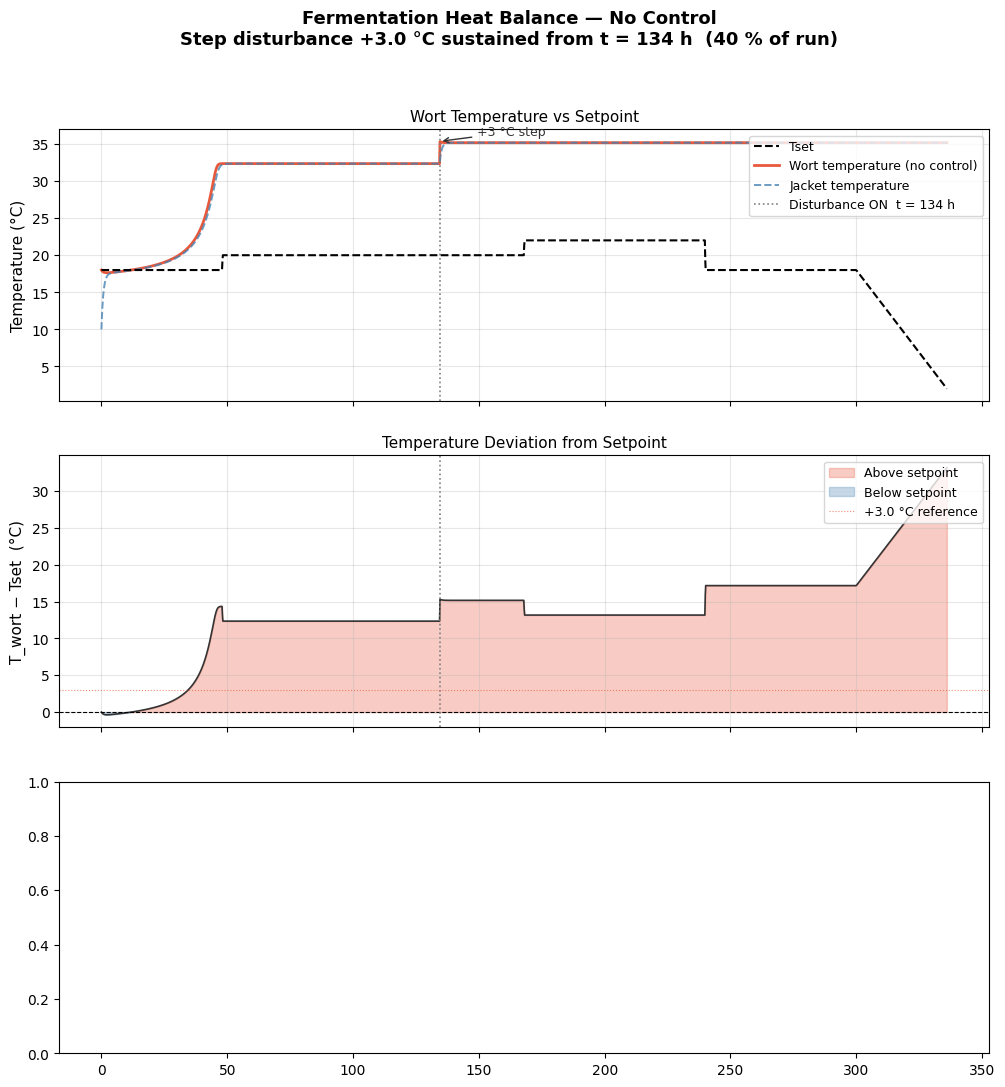

---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
File <command-6160678473333253>, line 58
     56 # ── Panel 3: Fixed coolant flow (for reference) ───────────────
     57 ax = axes[2]
---> 58 ax.axhline(F_coolant_m3h * 1000, color='steelblue', linewidth=2.0,
     59            label=f'Fixed coolant flow = {F_coolant_m3h*1000:.0f} L/hr')
     60 ax.axvline(t_disturbance, color='grey', linestyle=':', linewidth=1.2,
     61            label=f'Disturbance ON  t = {t_disturbance:.0f} h')
     62 ax.set_ylim(0, 20)

NameError: name 'F_coolant_m3h' is not defined

In [0]:
# ─────────────────────────────────────────────────────────────
#  PLOTS
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
fig.suptitle(
    "Fermentation Heat Balance — No Control\n"
    f"Step disturbance +{disturbance_dT} °C sustained from t = {t_disturbance:.0f} h  (40 % of run)",
    fontsize=13, fontweight='bold'
)

# ── Panel 1: Wort temperature ─────────────────────────────────
ax = axes[0]
ax.plot(t_out, Tset_C,  'k--', linewidth=1.5, label='Tset',        zorder=5)
ax.plot(t_out, T_C,     color='#E8593C', linewidth=2.0, label='Wort temperature (no control)')
ax.plot(t_out, Tc_C,    color='steelblue', linewidth=1.4,
        linestyle='--', label='Jacket temperature', alpha=0.8)
ax.axvline(t_disturbance, color='grey', linestyle=':', linewidth=1.2,
           label=f'Disturbance ON  t = {t_disturbance:.0f} h')

# Annotate the temperature jump.
# idx_dist   = last point of segment 1 (before step)
# idx_dist_1 = first point of segment 2, 1 h in (after step)
# We use the pre-step value from segment 1's final state directly.
T_before = sol1.y[5, -1] - 273.15          # exact pre-step wort temp
T_step   = T_before + disturbance_dT       # exact post-step wort temp
ax.annotate(
    f'+{disturbance_dT:.0f} °C step',
    xy=(t_disturbance, T_step),
    xytext=(t_disturbance + 15, T_step + 0.8),
    arrowprops=dict(arrowstyle='->', color='#333'),
    fontsize=9, color='#333'
)

ax.set_ylabel("Temperature (°C)", fontsize=11)
ax.set_title("Wort Temperature vs Setpoint", fontsize=11)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

# ── Panel 2: Temperature deviation from setpoint ──────────────
ax = axes[1]
deviation = T_C - Tset_C
ax.fill_between(t_out, deviation, 0,
                where=(deviation > 0), color='#E8593C', alpha=0.3, label='Above setpoint')
ax.fill_between(t_out, deviation, 0,
                where=(deviation < 0), color='steelblue', alpha=0.3, label='Below setpoint')
ax.plot(t_out, deviation, color='#333', linewidth=1.2)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(t_disturbance, color='grey', linestyle=':', linewidth=1.2)
ax.axhline( disturbance_dT, color='#E8593C', linewidth=0.8,
           linestyle=':', alpha=0.7, label=f'+{disturbance_dT} °C reference')
ax.set_ylabel("T_wort − Tset  (°C)", fontsize=11)
ax.set_title("Temperature Deviation from Setpoint", fontsize=11)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

# ── Panel 3: Fixed coolant flow (for reference) ───────────────
ax = axes[2]
ax.axhline(F_coolant_m3h * 1000, color='steelblue', linewidth=2.0,
           label=f'Fixed coolant flow = {F_coolant_m3h*1000:.0f} L/hr')
ax.axvline(t_disturbance, color='grey', linestyle=':', linewidth=1.2,
           label=f'Disturbance ON  t = {t_disturbance:.0f} h')
ax.set_ylim(0, 20)
ax.set_ylabel("Coolant Flow Rate (L/hr)", fontsize=11)
ax.set_xlabel("Time (h)", fontsize=11)
ax.set_title("Coolant Flow — Fixed (no controller)", fontsize=11)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig("/mnt/user-data/outputs/Disturbance_Only.png", dpi=150, bbox_inches='tight')
plt.show()

print("─── End of simulation ───────────────────────────────────")

In [0]:
threshold = 50

# Find index of peak VDK
i_peak = np.argmax(ppb_res)

# Look only after the peak
below_idx = np.where(ppb_res[i_peak:] < threshold)[0]

if len(below_idx) > 0:
    t_below_50 = t_out[i_peak + below_idx[0]]
    print(f"VDK drops below 50 ppb after peak at t = {t_below_50:.2f} hours")
else:
    print("VDK never drops below 50 ppb after the peak")